# Shoreline Detection using K-means

## Method overview (add diagram)

## Data grouping

In [215]:
# read all file name in "data\Planet_data"

import os
from datetime import datetime

planet_data_dir = "data/Planet_data_EPSG28992"
file_names = os.listdir(planet_data_dir)

# remove all names that have ".aux.xml" in them
file_names = [name for name in file_names if not name.endswith(".aux.xml")] 
# print(file_names)

# divide files into seasons based on leading YYYY-MM-DD in the filename
tif_files = [fn for fn in file_names if fn.lower().endswith(".tif") and len(fn) >= 10]

seasons = {"early": [], "mid": [], "late": []}
for fn in tif_files:
    try:
        dt = datetime.strptime(fn[:10], "%Y-%m-%d")
    except Exception:
        continue
    m = dt.month
    if 1 <= m <= 3:
        seasons["early"].append(fn)
    elif 4 <= m <= 9:
        seasons["mid"].append(fn)
    else:
        seasons["late"].append(fn)

# sort each season by date
for k in seasons:
    seasons[k].sort(key=lambda s: datetime.strptime(s[:10], "%Y-%m-%d"))

print({k: len(v) for k, v in seasons.items()})
seasons

{'early': 9, 'mid': 9, 'late': 7}


{'early': ['2017-03-16_strip_435861_composite.tif',
  '2018-02-22_strip_1201956_composite.tif',
  '2019-02-15_strip_2122432_composite.tif',
  '2020-02-07_strip_3113467_composite.tif',
  '2021-03-02_strip_4218715_composite.tif',
  '2022-03-08_strip_5468490_composite.tif',
  '2023-02-27_strip_6317538_composite.tif',
  '2024-03-02_strip_7145820_composite.tif',
  '2025-02-26_strip_7892478_composite.tif'],
 'mid': ['2017-07-06_strip_602670_composite.tif',
  '2018-06-29_strip_1532242_composite.tif',
  '2019-06-14_strip_2443911_composite.tif',
  '2020-06-24_strip_3512625_composite.tif',
  '2021-06-27_strip_4630194_composite.tif',
  '2022-06-21_strip_5728503_composite.tif',
  '2023-06-15_strip_6579851_composite.tif',
  '2024-06-23_strip_7392265_composite.tif',
  '2025-06-19_strip_8141392_composite.tif'],
 'late': ['2018-10-05_strip_1746499_composite.tif',
  '2019-10-16_strip_2755420_composite.tif',
  '2020-10-23_strip_3833704_composite.tif',
  '2021-10-15_strip_5001262_composite.tif',
  '2022-

In [216]:
from datetime import datetime

folder = "data\\Planet_data_EPSG28992\\"

summer_months = [
    "2025-06-19_strip_8141392_composite.tif",
    "2024-06-23_strip_7392265_composite.tif",
    "2023-06-15_strip_6579851_composite.tif",
    #"2022-10-09_strip_5992163_composite.tif",
    "2022-06-21_strip_5728503_composite.tif",
    "2021-06-27_strip_4630194_composite.tif",
    "2020-06-24_strip_3512625_composite.tif",
    "2019-06-14_strip_2443911_composite.tif",
    "2018-06-29_strip_1532242_composite.tif",
    "2017-07-06_strip_602670_composite.tif"
]

winter_months = [
    "2025-02-26_strip_7892478_composite.tif",
    "2024-10-05_strip_7618271_composite.tif",
    "2020-10-23_strip_3833704_composite.tif",
    "2020-02-07_strip_3113467_composite.tif",
    "2019-10-16_strip_2755420_composite.tif",
    "2019-02-15_strip_2122432_composite.tif",
    "2018-10-05_strip_1746499_composite.tif",
    "2018-02-22_strip_1201956_composite.tif",
    "2017-10-15_strip_838927_composite.tif"
]

# Sort lists by the leading YYYY-MM-DD date (ascending)
def _sort_by_date(lst):
    return sorted(lst, key=lambda s: datetime.strptime(s[:10], "%Y-%m-%d"))

summer_months = _sort_by_date(summer_months)
winter_months = _sort_by_date(winter_months)

In [253]:
# Replace summer_months with selected_files for subsequent operations

season_name = "late"
selected_files = seasons[season_name]

In [254]:
# print elements in selected_files and file sizes
import os
for fname in selected_files:
    fpath = os.path.join(folder, fname)
    if os.path.exists(fpath):
        fsize = os.path.getsize(fpath) / (1024 * 1024)
        print(f"{fname}: {fsize:.2f} MB")
    else:
        print(f"{fname}: file not found")

2018-10-05_strip_1746499_composite.tif: 27.22 MB
2019-10-16_strip_2755420_composite.tif: 27.22 MB
2020-10-23_strip_3833704_composite.tif: 27.22 MB
2021-10-15_strip_5001262_composite.tif: 27.22 MB
2022-10-09_strip_5992163_composite.tif: 27.22 MB
2023-10-17_strip_6840706_composite.tif: 27.22 MB
2024-10-05_strip_7618271_composite.tif: 27.22 MB


## Image processing

File: 2018-10-05_strip_1746499_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2019-10-16_strip_2755420_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2020-10-23_strip_3833704_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2021-10-15_strip_5001262_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2022-10-09_strip_5992163_composite.tif
Shape: (4, 1966, 1814)
Size: 5442.028604856896 x 5898.031001735753 meters
Resolution: 3.0000157689398543 x 3.0000157689398543 meters
Bands: 4
File: 2023-10-17_strip_6840706_composite.tif
Shape: (4, 1966, 181

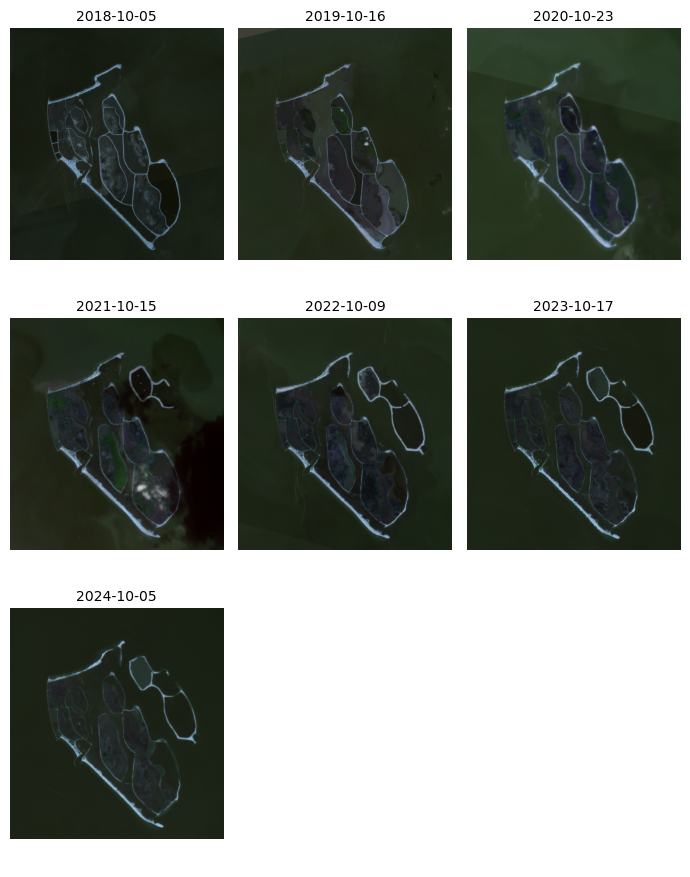

Saved figure to: python_gen_img/late_original_img.png


In [255]:
import os
import rasterio
import numpy as np
from rasterio.plot import reshape_as_image

# plot all tif files in selected_files in a subplot of 3x3

import matplotlib.pyplot as plt

n_row = len(selected_files) // 3 + (1 if len(selected_files) % 3 != 0 else 0)
n_col = 3

fig, axes = plt.subplots(n_row, n_col, figsize=(7, 9))
axes = axes.flatten()

for ax, fname in zip(axes, selected_files):
    path = os.path.join(folder, fname)
    try:
        with rasterio.open(path) as src:
            data = src.read()  # (bands, h, w)
            # print shape of data, size in meters, resolution, and available bands
            print(f"File: {fname}")
            print(f"Shape: {data.shape}")
            print(f"Size: {src.width * src.res[0]} x {src.height * src.res[1]} meters")
            print(f"Resolution: {src.res[0]} x {src.res[1]} meters")
            print(f"Bands: {src.count}")

            # use first 3 bands for RGB (pad if fewer bands)
            if data.shape[0] >= 3:
                rgb = data[:3]
            else:
                pad = np.zeros((3 - data.shape[0],) + data.shape[1:], dtype=data.dtype)
                rgb = np.vstack([data, pad])
            img = reshape_as_image(rgb)  # (h, w, 3)
            # normalize for display
            if img.dtype == np.uint8:
                img_disp = img / 255.0
            else:
                vmax = img.max() if img.max() != 0 else 1
                img_disp = img.astype("float32") / vmax
            ax.imshow(img_disp)
            ax.set_title(fname[:10], fontsize=10)
    except Exception:
        ax.text(0.5, 0.5, "Could not open\n" + fname, ha="center", va="center", fontsize=8)
    ax.axis("off")

# turn off any unused axes
for ax in axes[len(selected_files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

img_folder = "python_gen_img/"
out_img = os.path.join(img_folder, f"{season_name}_original_img.png")
os.makedirs(os.path.dirname(out_img), exist_ok=True)
fig.savefig(out_img, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_img}")


In [256]:
from scipy.ndimage import convolve

def contrast_stretch_tif(input_path, output_path=None, p_low=2, p_high=98, per_band=True, force_uint8=False):
    """
    Contrast-stretch a GeoTIFF and optionally save result.

    Parameters
    - input_path: path to source tif
    - output_path: path to save result. If None, function returns stretched array (bands, h, w).
      If endswith .png/.jpg/.jpeg the first 3 bands (or padded) are saved as an 8-bit RGB image.
      If endswith .tif the stretched raster is saved with georeference preserved.
    - p_low, p_high: percentiles to use for stretch (per band if per_band=True).
    - per_band: if True compute percentiles per band, otherwise compute across all bands.
    - force_uint8: when writing a GeoTIFF, force output dtype to uint8 (0-255).

    Returns:
    - stretched: numpy array (bands, h, w) with float32 values in [0,1] if output_path is None or for convenience.
    - If output saved, also returns output_path.
    """
    with rasterio.open(input_path) as src:
        meta = src.meta.copy()
        arr = src.read().astype("float32")  # shape (bands, h, w)
        bands, h, w = arr.shape

        # compute percentiles
        if per_band:
            lows = []
            highs = []
            for i in range(bands):
                band = arr[i]
                low, high = np.percentile(band, (p_low, p_high))
                lows.append(float(low))
                highs.append(float(high))
            lows = np.array(lows, dtype="float32")
            highs = np.array(highs, dtype="float32")
        else:
            low, high = np.percentile(arr, (p_low, p_high))
            lows = np.full(bands, float(low), dtype="float32")
            highs = np.full(bands, float(high), dtype="float32")

        # apply stretch per band -> produce float32 [0,1]
        stretched = np.zeros_like(arr, dtype="float32")
        for i in range(bands):
            b = arr[i]
            lo = lows[i]
            hi = highs[i] if highs[i] > lows[i] else (b.max() if b.max() != 0 else 1.0)
            stretched_band = (b - lo) / (hi - lo)
            stretched[i] = np.clip(stretched_band, 0.0, 1.0)
        
        # # sharpen stretch effect using a convolutional sharpening kernel
        # kernel = np.array([[0, -1, 0],
        #            [-1, 5, -1],
        #            [0, -1, 0]], dtype="float32")  # simple 3x3 sharpen
        # for i in range(bands):
        #     stretched[i] = np.clip(convolve(stretched[i], kernel, mode="reflect"), 0.0, 1.0)

    # if no output requested, return stretched (bands, h, w)
    if output_path is None:
        return stretched

    out_lower = output_path.lower()
    # save as image (PNG/JPEG) using first 3 bands, padded if necessary
    if out_lower.endswith((".png", ".jpg", ".jpeg")):
        # prepare HxWx3 image
        if bands >= 3:
            rgb = np.stack([stretched[0], stretched[1], stretched[2]], axis=-1)
        else:
            # pad missing bands with zeros
            pad = np.zeros((h, w, 3 - bands), dtype="float32")
            rgb = np.concatenate([stretched.transpose(1, 2, 0), pad], axis=-1)
        rgb8 = (np.clip(rgb, 0.0, 1.0) * 255).astype("uint8")
        plt.imsave(output_path, rgb8)
        return output_path

    # save as GeoTIFF: convert back to appropriate dtype
    if out_lower.endswith(".tif") or out_lower.endswith(".tiff"):
        dst_meta = meta.copy()
        # choose output dtype
        src_dtype = meta.get("dtype", "uint8")
        if force_uint8:
            dst_dtype = "uint8"
        else:
            # preserve original integer dtype if integer, otherwise use float32
            if np.issubdtype(np.dtype(src_dtype), np.integer):
                dst_dtype = src_dtype
            else:
                dst_dtype = "float32"

        dst_meta.update({
            "dtype": dst_dtype,
            "count": bands
        })

        # scale stretched to destination dtype range
        if np.issubdtype(np.dtype(dst_dtype), np.integer):
            info = np.iinfo(dst_dtype)
            scale_max = info.max
            out_arr = (stretched * scale_max).round().astype(dst_dtype)
        else:
            out_arr = stretched.astype(dst_dtype)

        with rasterio.open(output_path, "w", **dst_meta) as dst:
            dst.write(out_arr)

        return output_path

    # unsupported extension: just return stretched array
    return stretched

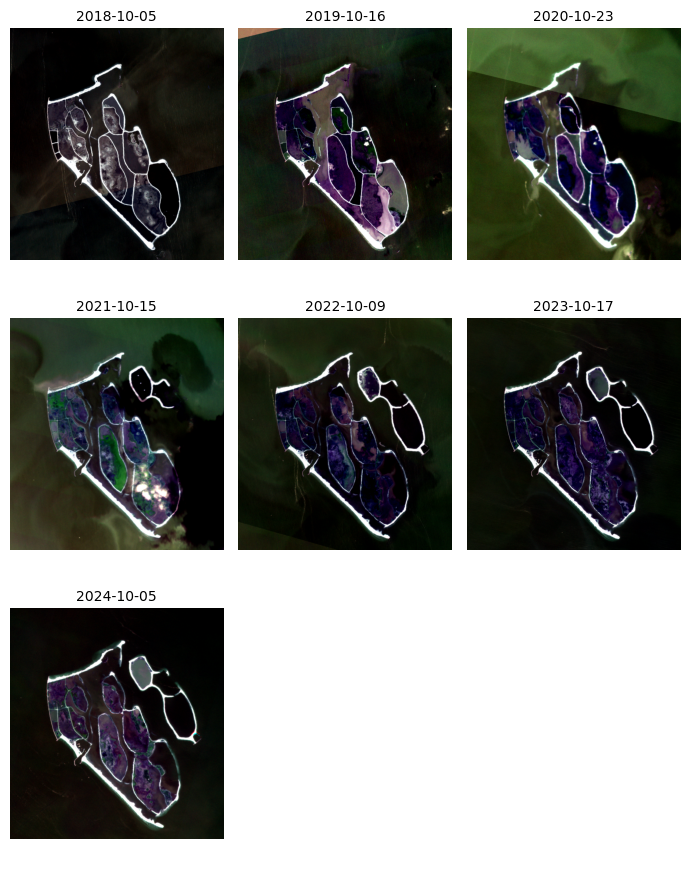

Saved figure to: python_gen_img/late_stretched.png


In [257]:
# apply contrast stretch to all selected_files and plot results in a subplot of 3 col x len(selected_files)//3 rows
# create a fresh figure/axes here to avoid showing an empty/other figure
fig, axes = plt.subplots(n_row, n_col, figsize=(7, 9))
axes_arr = axes.flatten()

for ax, fname in zip(axes_arr, selected_files):
    ax.clear()
    path = os.path.join(folder, fname)
    try:
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)  # (bands, h, w) float32 [0,1]
        bands, h, w = stretched.shape

        # prepare HxWx3 image (pad if fewer than 3 bands)
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((h, w, 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        ax.imshow(np.clip(rgb, 0.0, 1.0))
        ax.set_title(fname[:10], fontsize=10)
    except Exception as e:
        ax.text(0.5, 0.5, "Could not open\n" + fname, ha="center", va="center", fontsize=8)
        print(f"Error processing {fname}: {e}")
    ax.axis("off")

# turn off any unused axes
for ax in axes_arr[len(selected_files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

out_path = os.path.join(img_folder, f"{season_name}_stretched.png")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_path}")

## Water occurance probability --> water mask

Processed 2018-10-05_strip_1746499_composite.tif: water pixels = 3402229
Processed 2019-10-16_strip_2755420_composite.tif: water pixels = 3381944
Processed 2020-10-23_strip_3833704_composite.tif: water pixels = 3416803
Processed 2021-10-15_strip_5001262_composite.tif: water pixels = 3401359
Processed 2022-10-09_strip_5992163_composite.tif: water pixels = 3448101
Processed 2023-10-17_strip_6840706_composite.tif: water pixels = 3453628
Processed 2024-10-05_strip_7618271_composite.tif: water pixels = 3428244
Saved figure to: python_gen_img/late_water_prob.png


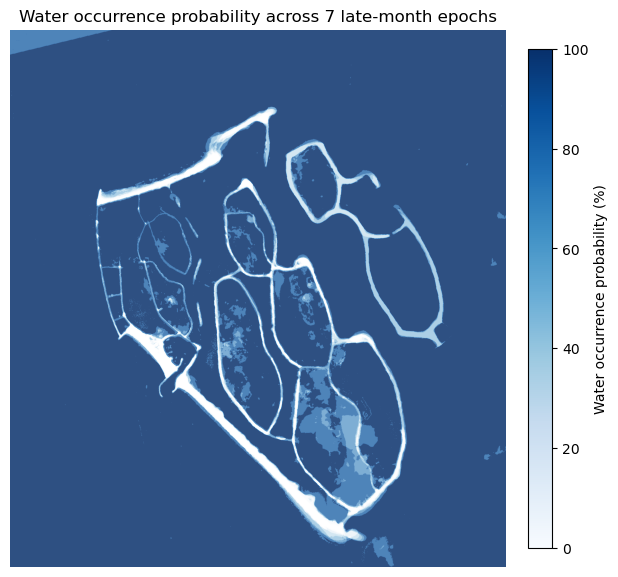

In [258]:
from sklearn.cluster import KMeans

# Water occurrence probability map
# overlay water areas from all summer epochs into one image
water_count = None
n_epochs = 0

for fname in selected_files:
    path = os.path.join(folder, fname)
    try:
        # get contrast-stretched data and RGB (HxWx3)
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        h, w, _ = rgb.shape
        flat = rgb.reshape(-1, 3)
        # cluster pixels into 2 classes
        km = KMeans(n_clusters=2, random_state=0)
        km.fit(flat)
        labels = km.labels_.reshape(h, w)
        counts = np.bincount(labels.flatten(), minlength=2)
        # assume water is the larger class (change from argmin to argmax)
        water_label = int(np.argmax(counts))
        water_mask = (labels == water_label).astype("uint8")

        if water_count is None:
            water_count = np.zeros((h, w), dtype="uint16")
        water_count += water_mask
        n_epochs += 1
        print(f"Processed {fname}: water pixels = {counts[water_label]}")
    except Exception as e:
        print(f"Skipping {fname}: {e}")

if water_count is None:
    raise RuntimeError("No valid images processed.")

# visualize: base = first epoch's stretched RGB (recompute if needed)
base_stretched = contrast_stretch_tif(os.path.join(folder, selected_files[4]), output_path=None, p_low=10, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)

# show base image and overlay heatmap of water frequency
frac = water_count.astype("float32") / float(n_epochs)
water_prob = frac * 100  # percentage
plt.figure(figsize=(7, 7))
# plt.imshow(np.clip(base_rgb, 0.0, 1.0))
# overlay blue heatmap, alpha proportional to fraction (use 'Blues' or 'cool' colormap)
cax = plt.imshow(water_prob, cmap="Blues", vmin=0, vmax=100, alpha=np.clip(frac * 0.85, 0, 0.85))
plt.title(f"Water occurrence probability across {n_epochs} {season_name}-month epochs")
plt.axis("off")
cb = plt.colorbar(cax, fraction=0.046, pad=0.04)
cb.set_label("Water occurrence probability (%)")

out_path = os.path.join(img_folder, f"{season_name}_water_prob.png")
plt.gcf().savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_path}")
plt.show()

### Water mask

In [259]:
np.unique(water_prob) # check unique values in water probability map

array([  0.      ,  14.285715,  28.57143 ,  42.857143,  57.14286 ,
        71.42857 ,  85.71429 , 100.      ], dtype=float32)

Saved figure to: python_gen_img/late_water_mask_80.png


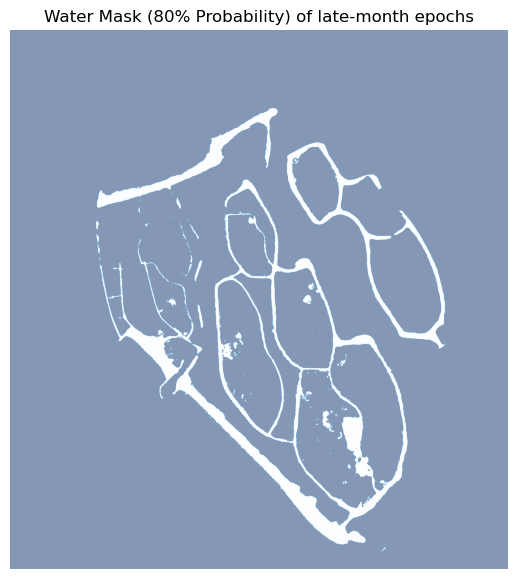

In [260]:
# Create water mask: pixels with water_prob < 10% are considered water (mask=1), else non-water (mask=0)

threshold = 80
water_mask = (water_prob > threshold).astype("uint8")

# plot water mask
plt.figure(figsize=(7, 7))
plt.imshow(water_mask, cmap="Blues", alpha=0.5)
plt.title(f"Water Mask ({threshold}% Probability) of {season_name}-month epochs")
plt.axis("off")

# save plotted water mask PNG
out_mask_png = os.path.join(img_folder, f"{season_name}_water_mask_{threshold}.png")
os.makedirs(os.path.dirname(out_mask_png), exist_ok=True)
plt.gcf().savefig(out_mask_png, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_mask_png}")

plt.show()

In [261]:
water_mask

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)

## K-means

Saved figure to: python_gen_img/early_kmeans.png


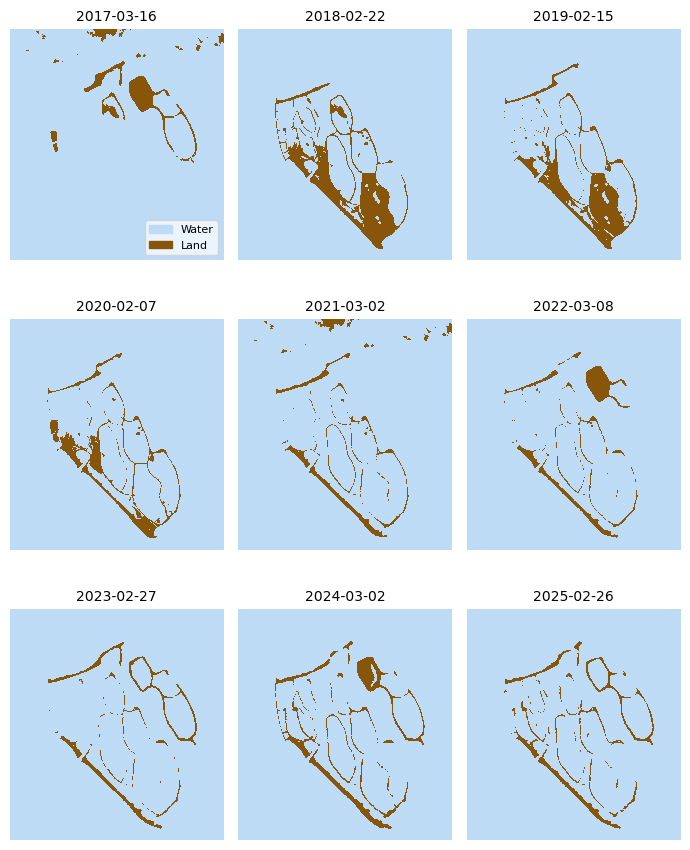

In [226]:
# k-means clustering plots in a single subplot grid with 3 columns
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

n = len(selected_files)
n_col = 3
n_row = (n + n_col - 1) // n_col

fig, axes = plt.subplots(n_row, n_col, figsize=(7, 9))
axes = axes.flatten() if n > 1 else [axes]

# consistent colormap: index 0 = land (brown), 1 = water (blue)
cmap = ListedColormap(["#88560b", "#BEDBF5"])
norm = BoundaryNorm(np.arange(-0.5, 2.5), cmap.N)

first_legend = True
for ax, fname in zip(axes, selected_files):
    ax.clear()
    path = os.path.join(folder, fname)
    try:
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            img = stretched[:3].transpose(1, 2, 0)  # HxWx3
        else:
            img = stretched.transpose(1, 2, 0)
            pad = np.zeros((img.shape[0], img.shape[1], 3 - img.shape[2]), dtype="float32")
            img = np.concatenate([img, pad], axis=2)

        h, w, _ = img.shape
        flat = img.reshape(-1, 3)

        km = KMeans(n_clusters=2, random_state=0).fit(flat)
        labels = km.labels_.reshape(h, w)

        counts = np.bincount(labels.flatten(), minlength=2)
        water_label = int(np.argmax(counts))
        land_label = int(np.argmin(counts))

        # remap to (0=land, 1=water)
        labels_remap = np.zeros_like(labels)
        labels_remap[labels == water_label] = 1
        labels_remap[labels == land_label] = 0
        labels = labels_remap

        # optionally enforce the global water_mask (keeps previous behavior) # help with inconsistent clustering
        labels = np.where(water_mask == 1, 1, labels)

        ax.imshow(labels, cmap=cmap, norm=norm, origin="upper")
        ax.set_title(fname[:10], fontsize=10)
        ax.axis("off")

        # add legend only once
        if first_legend:
            patches = [mpatches.Patch(color="#BEDBF5", label="Water"),
                       mpatches.Patch(color="#88560b", label="Land")]
            ax.legend(handles=patches, loc="lower right", framealpha=0.7, fontsize=8)
            first_legend = False

    except Exception as e:
        ax.text(0.5, 0.5, "Error\n" + fname, ha="center", va="center", fontsize=8)
        ax.axis("off")
        print(f"Error processing {fname}: {e}")

# turn off unused axes
for ax in axes[len(selected_files):]:
    ax.axis("off")

plt.tight_layout()

# save img
out_kmeans = os.path.join(img_folder, f"{season_name}_kmeans.png")
os.makedirs(os.path.dirname(out_kmeans), exist_ok=True)
fig.savefig(out_kmeans, dpi=150, bbox_inches="tight")
print(f"Saved figure to: {out_kmeans}")

plt.show()


## Land occurrance probability map (not use in report)

Processed 2017-03-16_strip_435861_composite.tif: land pixels = 1418813
Processed 2018-02-22_strip_1201956_composite.tif: land pixels = 509382
Processed 2018-02-22_strip_1201956_composite.tif: land pixels = 509382
Processed 2019-02-15_strip_2122432_composite.tif: land pixels = 333878
Processed 2019-02-15_strip_2122432_composite.tif: land pixels = 333878
Processed 2020-02-07_strip_3113467_composite.tif: land pixels = 186339
Processed 2020-02-07_strip_3113467_composite.tif: land pixels = 186339
Processed 2021-03-02_strip_4218715_composite.tif: land pixels = 145789
Processed 2021-03-02_strip_4218715_composite.tif: land pixels = 145789
Processed 2022-03-08_strip_5468490_composite.tif: land pixels = 149134
Processed 2022-03-08_strip_5468490_composite.tif: land pixels = 149134
Processed 2023-02-27_strip_6317538_composite.tif: land pixels = 127275
Processed 2023-02-27_strip_6317538_composite.tif: land pixels = 127275
Processed 2024-03-02_strip_7145820_composite.tif: land pixels = 625340
Proces

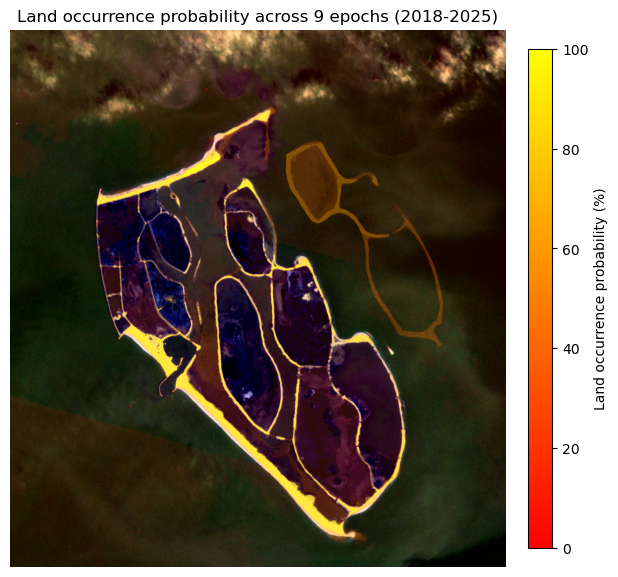

In [227]:
# Land occurrance probability map
# overlay land areas from all summer epochs into one image
land_count = None
n_epochs = 0

for fname in selected_files:
    path = os.path.join(folder, fname)
    try:
        # get contrast-stretched data and RGB (HxWx3)
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        h, w, _ = rgb.shape
        flat = rgb.reshape(-1, 3)
        # cluster pixels into 2 classes
        km = KMeans(n_clusters=2, random_state=0)
        km.fit(flat)
        labels = km.labels_.reshape(h, w)
        counts = np.bincount(labels.flatten(), minlength=2)
        # assume land is the smaller class (adjust logic if you prefer another heuristic)
        land_label = int(np.argmin(counts))
        land_mask = (labels == land_label).astype("uint8")

        if land_count is None:
            land_count = np.zeros((h, w), dtype="uint16")  # can hold counts up to many epochs
        land_count += land_mask
        n_epochs += 1
        print(f"Processed {fname}: land pixels = {counts[land_label]}")
    except Exception as e:
        print(f"Skipping {fname}: {e}")

if land_count is None:
    raise RuntimeError("No valid images processed.")

# visualize: base = first epoch's stretched RGB (recompute if needed)
base_stretched = contrast_stretch_tif(os.path.join(folder, selected_files[4]), output_path=None, p_low=10, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)

# show base image and overlay heatmap of land frequency
frac = land_count.astype("float32") / float(n_epochs)
land_prob = frac * 100  # percentage
plt.figure(figsize=(7, 7))
plt.imshow(np.clip(base_rgb, 0.0, 1.0))
# overlay red heatmap, alpha proportional to fraction
cax = plt.imshow(land_prob, cmap="autumn", vmin=0, vmax=100, alpha=np.clip(frac * 0.85, 0, 0.85))
plt.title(f"Land occurrence probability across {len(selected_files)} epochs (2018-2025)")
plt.axis("off")
cb = plt.colorbar(cax, fraction=0.046, pad=0.04)
cb.set_label("Land occurrence probability (%)")
plt.show()


## Coastline extraction & contour plots

In [228]:
# extract coastlines from k-means results (after remapping) and smooth them
from scipy.ndimage import binary_erosion
from rasterio.features import shapes
from shapely.geometry import shape, mapping
import json

def chaikin_smooth_coords(coords, iterations=2, closed=False):
    """
    Chaikin subdivision smoothing for a list of (x,y) coords.
    closed=True treats the polyline as a closed loop.
    """
    if len(coords) < 2:
        return coords
    pts = list(coords)
    for _ in range(iterations):
        new_pts = []
        if closed:
            n = len(pts)
            for i in range(n):
                p0 = np.array(pts[i])
                p1 = np.array(pts[(i + 1) % n])
                q = 0.75 * p0 + 0.25 * p1
                r = 0.25 * p0 + 0.75 * p1
                new_pts.append(tuple(q))
                new_pts.append(tuple(r))
            pts = new_pts
        else:
            # open polyline: keep endpoints, smooth interior
            new_pts.append(pts[0])
            for i in range(len(pts) - 1):
                p0 = np.array(pts[i])
                p1 = np.array(pts[i + 1])
                q = 0.75 * p0 + 0.25 * p1
                r = 0.25 * p0 + 0.75 * p1
                new_pts.append(tuple(q))
                new_pts.append(tuple(r))
            new_pts.append(pts[-1])
            pts = new_pts
    return pts

def smooth_shapely_geom(shp, iterations=2):
    """
    Smooth LineString / MultiLineString geometries using Chaikin smoothing.
    Returns a shapely geometry of the same top-level type (LineString or MultiLineString).
    """
    from shapely.geometry import LineString, MultiLineString
    if shp.is_empty:
        return shp
    if shp.geom_type == "LineString":
        coords = list(shp.coords)
        closed = (coords[0] == coords[-1])
        if len(coords) <= 3:
            return shp  # too short to meaningfully smooth
        new_coords = chaikin_smooth_coords(coords, iterations=iterations, closed=closed)
        # ensure we keep a valid LineString (at least 2 points)
        return LineString(new_coords) if len(new_coords) >= 2 else shp
    elif shp.geom_type == "MultiLineString":
        parts = []
        for part in shp.geoms:
            s = smooth_shapely_geom(part, iterations=iterations)
            if not s.is_empty:
                parts.append(s)
        return MultiLineString(parts) if parts else shp
    else:
        return shp  # don't alter non-line geometries here

coastlines = {}  # fname -> list of GeoJSON-like geometries (LineString / MultiLineString)
for fname in selected_files:
    path = os.path.join(folder, fname)
    try:
        with rasterio.open(path) as src:
            # get contrast-stretched RGB (HxWx3)
            stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
            if stretched.shape[0] >= 3:
                rgb = stretched[:3].transpose(1, 2, 0)
            else:
                rgb = stretched.transpose(1, 2, 0)
                pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
                rgb = np.concatenate([rgb, pad], axis=2)

            h, w, _ = rgb.shape
            flat = rgb.reshape(-1, 3)

            # cluster into 2 classes and remap as before (land_label = smaller class)
            km = KMeans(n_clusters=2, random_state=0).fit(flat)
            labels = km.labels_.reshape(h, w)

            # counts = np.bincount(labels.flatten(), minlength=2)
            # land_label = int(np.argmin(counts))
            # land_mask = (labels == land_label)

            # determine which cluster is water (more number of cells) and which is land (lower number of cells)
            counts = np.bincount(labels.flatten())
            water_label = int(np.argmax(counts))
            land_label = int(np.argmin(counts))
            # print(f"Water label: {water_label}, Land label: {land_label}")
            # print counts of water and land pixels
            # print(f"Water pixels: {counts[water_label]}, Land pixels: {counts[land_label]}")

            # Remap labels: water=1, land=0
            labels_remap = np.zeros_like(labels)
            labels_remap[labels == water_label] = 1
            labels_remap[labels == land_label] = 0
            labels = labels_remap

            # apply water_mask to filter out non-water areas
            # note that in water_mask, water=1, non-water=0
            # Retain only water areas within the water_mask boundary
            labels = np.where(water_mask == 1, 1, labels) 

            land_mask = (labels == 0)  # land=1, water=0

            # get 1-px wide land-edge (boundary of land regions)
            eroded = binary_erosion(land_mask, structure=np.ones((3, 3)))
            land_boundary_mask = land_mask & (~eroded)

            # Vectorize land polygons then extract polygon boundaries (preferred)
            geom_lines = []
            for geom, val in shapes(land_mask.astype("uint8"), mask=None, transform=src.transform):
                if int(val) == 1:
                    poly = shape(geom)
                    boundary = poly.boundary
                    if not boundary.is_empty:
                        smooth_b = smooth_shapely_geom(boundary, iterations=2)
                        geom_lines.append(mapping(smooth_b))

            # fallback: if no polygons produced, vectorize pixel-boundary mask directly
            if not geom_lines:
                for geom, val in shapes(land_boundary_mask.astype("uint8"), mask=None, transform=src.transform):
                    if int(val) == 1:
                        shp = shape(geom) if not hasattr(geom, "geom_type") else geom
                        smooth_shp = smooth_shapely_geom(shp, iterations=2) if hasattr(shp, "geom_type") else shp
                        geom_lines.append(mapping(smooth_shp))

            coastlines[fname] = geom_lines

            # save per-file GeoJSON of coastlines
            features = [{"type": "Feature", "properties": {"source": fname}, "geometry": g} for g in geom_lines]
            out_geojson = os.path.join(folder, fname.replace(".tif", "_coastlines.geojson"))
            with open(out_geojson, "w") as fh:
                json.dump({"type": "FeatureCollection", "features": features}, fh)

            print(f"{fname}: extracted {len(geom_lines)} (smoothed) coastline geometries -> {out_geojson}")
    except Exception as e:
        print(f"Skipping {fname}: {e}")

# coastlines dict now contains smoothed geometries for plotting/analysis


2017-03-16_strip_435861_composite.tif: extracted 1047 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2017-03-16_strip_435861_composite_coastlines.geojson
2018-02-22_strip_1201956_composite.tif: extracted 1048 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2018-02-22_strip_1201956_composite_coastlines.geojson
2018-02-22_strip_1201956_composite.tif: extracted 1048 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2018-02-22_strip_1201956_composite_coastlines.geojson
2019-02-15_strip_2122432_composite.tif: extracted 582 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2019-02-15_strip_2122432_composite_coastlines.geojson
2019-02-15_strip_2122432_composite.tif: extracted 582 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2019-02-15_strip_2122432_composite_coastlines.geojson
2020-02-07_strip_3113467_composite.tif: extracted 1461 (smoothed) coastline geometries -> data\Planet_data_EPSG28992\2020-02-07_strip_3113467_composi

C:\Users\Move\AppData\Local\Temp\ipykernel_6756\2769888121.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10" if n <= 10 else "tab20")
C:\Users\Move\AppData\Local\Temp\ipykernel_6756\2769888121.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{float(x):.0f}" for x in xtick_world], rotation=45)
C:\Users\Move\AppData\Local\Temp\ipykernel_6756\2769888121.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{float(y):.0f}" for y in ytick_world])
C:\Users\Move\AppData\Local\Temp\ipykernel_6756\2769888121.py:78: UserWarning: set_ticklabels() should only be used with a fixed

Saved image to: python_gen_img/early_4boxes_location.png


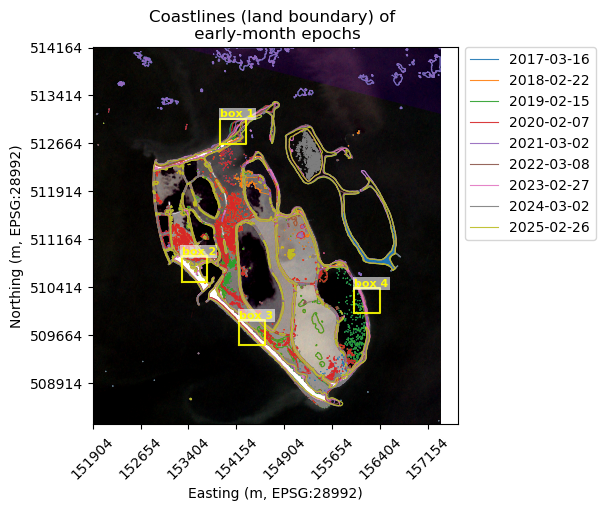

In [229]:
# plot extracted coastlines over base image (one color per epoch, legend with year)
import matplotlib.pyplot as plt
from shapely.geometry import shape as geom_shape
import matplotlib.cm as cm
import rasterio
import numpy as np

# use the first summer month as reference for transform and base image
ref_path = os.path.join(folder, selected_files[0])
with rasterio.open(ref_path) as ref_ds:
    ref_transform = ref_ds.transform

# compute base_rgb from the same reference file (first summer epoch)
base_stretched = contrast_stretch_tif(os.path.join(folder, selected_files[1]), output_path=None, p_low=15, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)

# prepare colors (one per summer epoch)
n = len(selected_files)
palette = cm.get_cmap("tab10" if n <= 10 else "tab20")
colors = [palette(i % palette.N) for i in range(n)]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# show base image; ensure origin='upper' so pixel coords align with row indices
ax.imshow(np.clip(base_rgb, 0.0, 1.0), origin="upper", aspect="equal")

# plot coastlines year-by-year with one legend entry per year
added_labels = set()
for i, fname in enumerate(selected_files):
    geom_list = coastlines.get(fname)
    if not geom_list:
        continue
    color = colors[i]
    label = fname[:10]  # YYYY-MM-DD
    first_plotted = False
    for geom in geom_list:
        # geom may already be a mapping (dict) or shapely-like; convert to shapely
        shp = geom_shape(geom) if not hasattr(geom, "geom_type") else geom
        # handle LineString and MultiLineString uniformly
        if shp.is_empty:
            continue
        if shp.geom_type == "LineString":
            lines = [shp]
        elif shp.geom_type == "MultiLineString":
            lines = list(shp.geoms)
        else:
            # skip non-line geometries
            continue

        for line in lines:
            coords = list(line.coords)
            if not coords:
                continue
            # convert world coords (x,y) -> pixel coords (col, row) using inverse transform
            inv = ~ref_transform
            pix = [inv * (x, y) for (x, y) in coords]  # list of (col, row)
            cols, rows = zip(*pix)
            # plot; add label only once per file to avoid duplicates in legend
            if (label not in added_labels) and (not first_plotted):
                ax.plot(cols, rows, color=color, linewidth=0.8, alpha=0.9, label=label)
                added_labels.add(label)
                first_plotted = True
            else:
                ax.plot(cols, rows, color=color, linewidth=0.8, alpha=0.9)

# finalize
ax.set_title(f"Coastlines (land boundary) of \n {season_name}-month epochs", fontsize=12)
# convert pixels to world coordinates for axis ticks
xticks = ax.get_xticks()
yticks = ax.get_yticks()
# ensure we transform each tick as a coordinate tuple, then pick the relevant component
xtick_world = [ (ref_transform * (x, 0))[0] for x in xticks ]
ytick_world = [ (ref_transform * (0, y))[1] for y in yticks ]
ax.set_xticklabels([f"{float(x):.0f}" for x in xtick_world], rotation=45)
ax.set_yticklabels([f"{float(y):.0f}" for y in ytick_world])
ax.set_xlabel("Easting (m, EPSG:28992)")
ax.set_ylabel("Northing (m, EPSG:28992)")
ax.axis("on")

# draw requested world-aligned boxes (convert world -> pixel using inverse transform)
boxes = [
    (153900, 512650, 153900+400, 512650+400),
    (153300, 510500, 153300+400, 510500+400),
    (154200, 509500, 154200+400, 509500+400),
    (156000, 510000, 156000+400, 510000+400),
]

inv = ~ref_transform
box_color = "yellow"

for idx, (bx_minx, bx_miny, bx_maxx, bx_maxy) in enumerate(boxes):
    # build world coords for box corners (closed polygon)
    world_corners = [
        (bx_minx, bx_miny),
        (bx_minx, bx_maxy),
        (bx_maxx, bx_maxy),
        (bx_maxx, bx_miny),
        (bx_minx, bx_miny),
    ]
    pix = [inv * (x, y) for (x, y) in world_corners]  # (col, row)
    cols, rows = zip(*pix)
    ax.plot(cols, rows, color=box_color, linewidth=1.5, alpha=0.9)
    # label as "box <n>" near the top-left corner
    ax.text(cols[1], rows[1] - 8, f"box {idx+1}", color=box_color, fontsize=8, weight="bold",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1))

# place legend outside the plot
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()

# ensure output folder exists and save the figure
out_img = os.path.join(img_folder, f"{season_name}_4boxes_location.png")
os.makedirs(os.path.dirname(out_img), exist_ok=True)
fig.savefig(out_img, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved image to: {out_img}")

plt.show()


Saved coastline overlay image to: python_gen_img/early_2017-03-16_coastlines_overlay.png


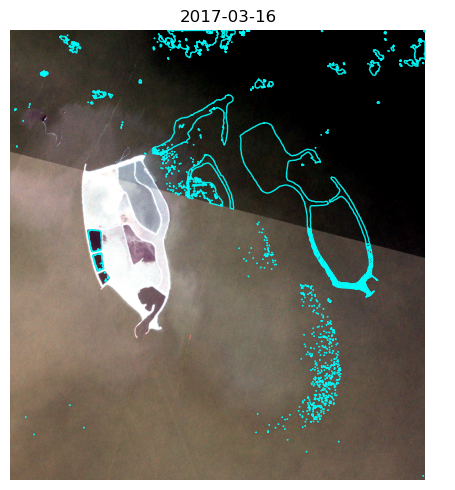

Saved coastline overlay image to: python_gen_img/early_2018-02-22_coastlines_overlay.png


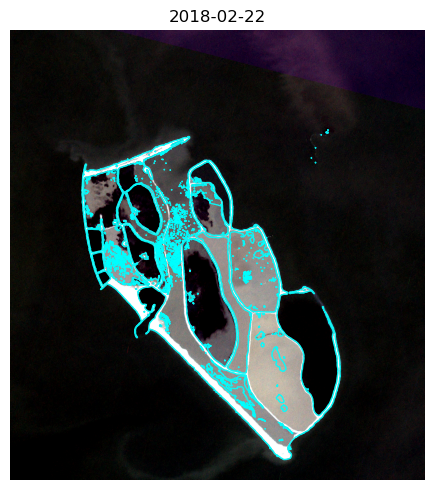

Saved coastline overlay image to: python_gen_img/early_2019-02-15_coastlines_overlay.png


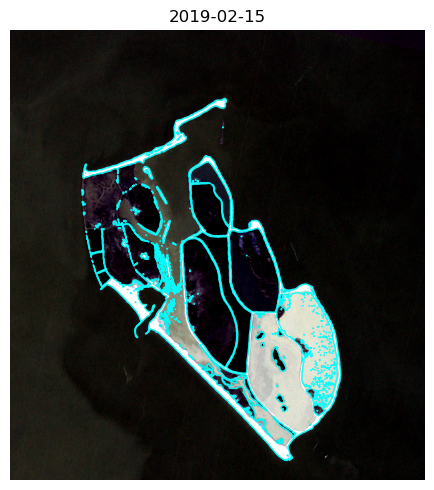

Saved coastline overlay image to: python_gen_img/early_2020-02-07_coastlines_overlay.png


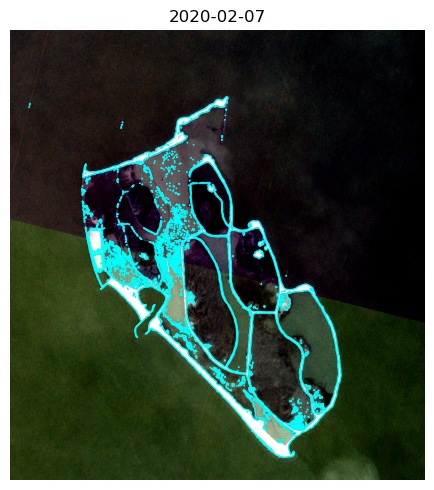

Saved coastline overlay image to: python_gen_img/early_2021-03-02_coastlines_overlay.png


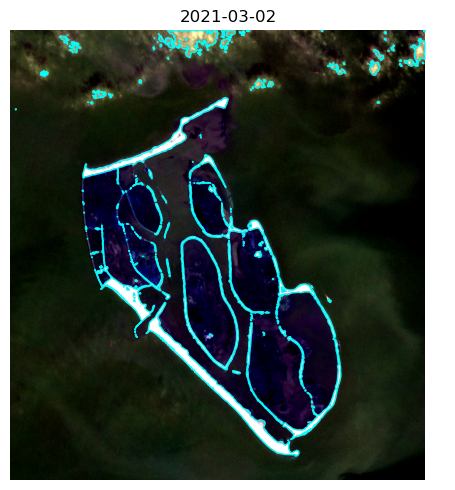

Saved coastline overlay image to: python_gen_img/early_2022-03-08_coastlines_overlay.png


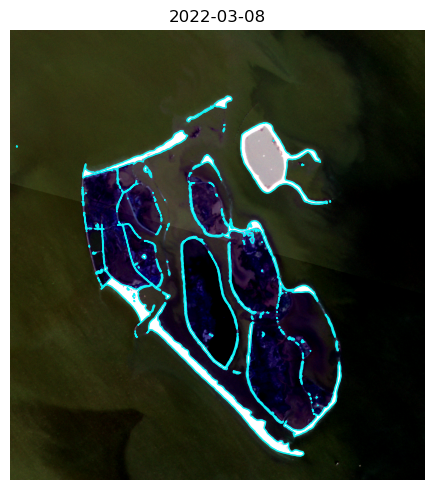

Saved coastline overlay image to: python_gen_img/early_2023-02-27_coastlines_overlay.png


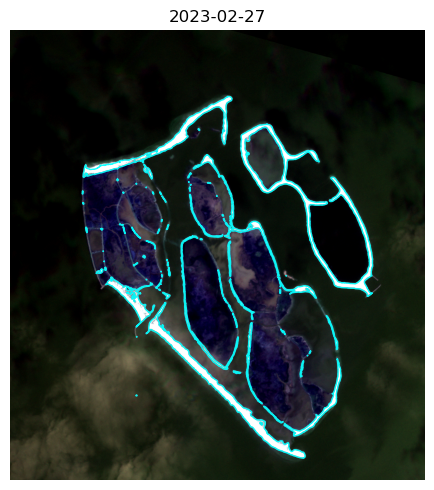

Saved coastline overlay image to: python_gen_img/early_2024-03-02_coastlines_overlay.png


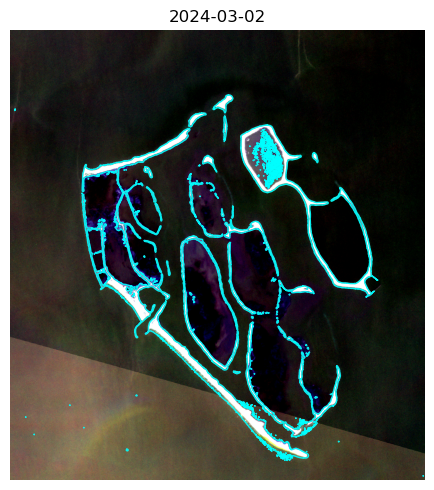

Saved coastline overlay image to: python_gen_img/early_2025-02-26_coastlines_overlay.png


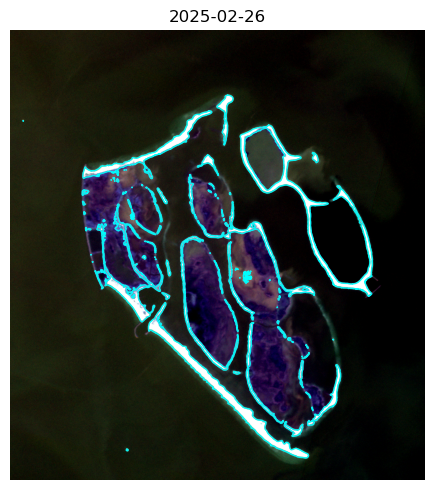

In [230]:
# plot one epoch at a time: base image + that epoch's coastlines
for fname in selected_files:
    path = os.path.join(folder, fname)
    try:
        # read transform for this raster (used to convert world->pixel)
        with rasterio.open(path) as ds:
            transform = ds.transform

        # get contrast-stretched RGB for this file
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            rgb = stretched[:3].transpose(1, 2, 0)
        else:
            rgb = stretched.transpose(1, 2, 0)
            pad = np.zeros((rgb.shape[0], rgb.shape[1], 3 - rgb.shape[2]), dtype="float32")
            rgb = np.concatenate([rgb, pad], axis=2)

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(np.clip(rgb, 0.0, 1.0), origin="upper", aspect="equal")

        geom_list = coastlines.get(fname, [])
        if geom_list:
            inv = ~transform
            for geom in geom_list:
                shp = geom_shape(geom) if not hasattr(geom, "geom_type") else geom
                if shp.is_empty:
                    continue
                # normalize to line(s)
                if shp.geom_type == "LineString":
                    lines = [shp]
                elif shp.geom_type == "MultiLineString":
                    lines = list(shp.geoms)
                else:
                    lines = [g for g in getattr(shp, "geoms", []) if g.geom_type == "LineString"]
                for line in lines:
                    coords = list(line.coords)
                    if not coords:
                        continue
                    pix = [inv * (x, y) for (x, y) in coords]  # (col, row)
                    cols, rows = zip(*pix)
                    ax.plot(cols, rows, color="cyan", linewidth=1.0, alpha=0.9)

        ax.set_title(fname[:10], fontsize=12)
        ax.axis("off")
        plt.tight_layout()

        out_img = os.path.join(img_folder, f"{season_name}_{fname[:10]}_coastlines_overlay.png")
        os.makedirs(os.path.dirname(out_img), exist_ok=True)
        fig.savefig(out_img, dpi=150, bbox_inches="tight")
        print(f"Saved coastline overlay image to: {out_img}")
        plt.show()

    except Exception as e:
        print(f"Error plotting {fname}: {e}")
        continue


Image size: 1814 1966
Crop window: 1365 1499 1254 1388
Bbox: 156000 510000 156400 510400


C:\Users\Move\AppData\Local\Temp\ipykernel_6756\2512179119.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10" if n <= 10 else "tab20")


Saved cropped coastline overlay image to: python_gen_img/early_box4_coastlines_overlay.png


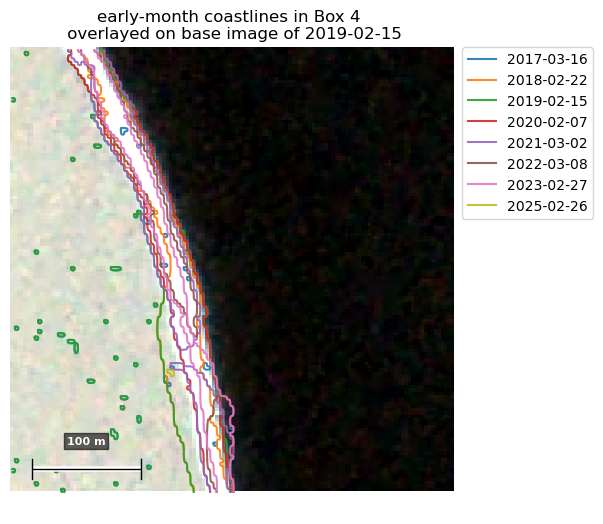

In [239]:
from shapely.geometry import box

# plot extracted coastlines over base image, cropped to bbox (world coords)
# minx, miny, maxx, maxy = 661180, 5827300, 661180+350, 5827300+350
# minx, miny, maxx, maxy = 155000, 508500, 155500, 509000

box_no = 3  # change to select a different box
minx, miny, maxx, maxy = boxes[box_no]  # use first box as example

# use the first summer month as reference for transform and base image
ref_path = os.path.join(folder, selected_files[0])
with rasterio.open(ref_path) as ref_ds:
    ref_transform = ref_ds.transform

# inverse transform: world -> pixel (col, row)
inv = ~ref_transform

# map bbox corners to pixel coords and build integer window (clamped to image)
tl = inv * (minx, maxy)  # top-left world -> pixel (col, row)
br = inv * (maxx, miny)  # bottom-right world -> pixel (col, row)

# get float bounds then integer window
col_min_f = min(tl[0], br[0])
col_max_f = max(tl[0], br[0])
row_min_f = min(tl[1], br[1])
row_max_f = max(tl[1], br[1])

col0 = int(np.floor(col_min_f))
row0 = int(np.floor(row_min_f))
col1 = int(np.ceil(col_max_f))
row1 = int(np.ceil(row_max_f))

# clamp to image bounds (ensure values stay within [0, w] and [0, h])
col0 = max(0, min(w, col0))
col1 = max(0, min(w, col1))
row0 = max(0, min(h, row0))
row1 = max(0, min(h, row1))

print("Image size:", w, h)
print("Crop window:", col0, col1, row0, row1)
print("Bbox:", minx, miny, maxx, maxy)

# if the window is empty after clamping, the bbox doesn't intersect the image
if col1 <= col0 or row1 <= row0:
    raise RuntimeError("Computed crop window is empty (bbox may lie outside the image).")

# define base_rgb
# compute base_rgb from the same reference file (first summer epoch)
base_img_name = selected_files[2]
base_stretched = contrast_stretch_tif(os.path.join(folder, base_img_name), output_path=None, p_low=15, p_high=98)
if base_stretched.shape[0] >= 3:
    base_rgb = base_stretched[:3].transpose(1, 2, 0)
else:
    base_rgb = base_stretched.transpose(1, 2, 0)
    pad = np.zeros((base_rgb.shape[0], base_rgb.shape[1], 3 - base_rgb.shape[2]), dtype="float32")
    base_rgb = np.concatenate([base_rgb, pad], axis=2)


# crop base image (pixel coordinates: rows, cols)
base_rgb_crop = base_rgb[row0:row1, col0:col1].copy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(np.clip(base_rgb_crop, 0.0, 1.0), origin="upper", aspect="equal")

# build bbox polygon once (world coordinates)
bbox_geom = box(minx, miny, maxx, maxy)

# plot coastlines clipped/translated into cropped pixel coordinates
legend_added = set()
n = len(selected_files)
palette = cm.get_cmap("tab10" if n <= 10 else "tab20")
colors_local = [palette(i % palette.N) for i in range(n)]

for i, fname in enumerate(selected_files):
    geom_list = coastlines.get(fname)
    if not geom_list:
        continue
    color = colors_local[i]
    label = fname[:10]

    for geom in geom_list:
        shp = geom_shape(geom) if not hasattr(geom, "geom_type") else geom
        if shp.is_empty:
            continue

        # quick bbox reject (optional; keeps performance)
        gb = shp.bounds  # (xmin, ymin, xmax, ymax)
        if (gb[2] < minx) or (gb[0] > maxx) or (gb[3] < miny) or (gb[1] > maxy):
            continue

        # clip to bbox so we only plot segments inside the bbox
        clipped = shp.intersection(bbox_geom)
        if clipped.is_empty:
            continue

        # normalize to a list of LineString segments
        lines = []
        if clipped.geom_type == "LineString":
            lines = [clipped]
        elif clipped.geom_type == "MultiLineString":
            lines = list(clipped.geoms)
        else:  # handle GeometryCollection that may contain lines
            for g in getattr(clipped, "geoms", []):
                if g.geom_type == "LineString":
                    lines.append(g)
                elif g.geom_type == "MultiLineString":
                    lines.extend(list(g.geoms))

        if not lines:
            continue

        first_plotted = False
        for line in lines:
            coords = list(line.coords)
            if not coords:
                continue
            # convert world coords to original pixel coords then to cropped pixel coords
            pix = [inv * (x, y) for (x, y) in coords]  # (col, row)
            cols, rows = zip(*pix)
            cols_local = np.array(cols) - col0
            rows_local = np.array(rows) - row0
            if (label not in legend_added) and (not first_plotted):
                ax.plot(cols_local, rows_local, color=color, linewidth=1.5, alpha=0.9, label=label)
                legend_added.add(label)
                first_plotted = True
            else:
                ax.plot(cols_local, rows_local, color=color, linewidth=1.5, alpha=0.9)

# finalize (with scalebar)
ax.set_title(f"{season_name}-month coastlines in Box {box_no + 1} \n overlayed on base image of {base_img_name[:10]}")

# draw scale bar (meters)
import math
# approximate meters-per-pixel (handles typical north-up and handles signed pixel height)
mpp_x = abs(ref_transform.a)
mpp_y = abs(ref_transform.e)
mpp = (mpp_x + mpp_y) / 2.0 if (mpp_x > 0 and mpp_y > 0) else (mpp_x or mpp_y)

# world width of crop (meters) -> choose a "nice" scale length <= 1/4 width
world_width = maxx - minx
candidates = [5000,2000,1000,500, 200, 100, 50, 20, 10, 5, 2, 1]  # in meters
scale_len_m = next((c for c in candidates if c <= (world_width / 4.0)), candidates[-1])

# pixel length of scale bar in the cropped image
ncols_crop = base_rgb_crop.shape[1]
nrows_crop = base_rgb_crop.shape[0]
px_len = max(1, int(round(scale_len_m / mpp)))

# position: 5% from left, 5% from bottom (origin='upper' so bottom ~ high row index)
x0 = int(ncols_crop * 0.05)
y0 = int(nrows_crop * 0.95)

# draw white bar with black edge for visibility
ax.plot([x0, x0 + px_len], [y0, y0], color='white', linewidth=4, solid_capstyle='butt', zorder=20)
ax.plot([x0, x0 + px_len], [y0, y0], color='black', linewidth=1, solid_capstyle='butt', zorder=21)

# small end ticks
tick_h = max(3, int(nrows_crop * 0.01))
ax.plot([x0, x0], [y0 - tick_h, y0 + tick_h], color='black', linewidth=1, zorder=21)
ax.plot([x0 + px_len, x0 + px_len], [y0 - tick_h, y0 + tick_h], color='black', linewidth=1, zorder=21)

# label centered above the bar
ax.text(x0 + px_len / 2.0, y0 - tick_h - 4, f"{scale_len_m} m",
        color='white', ha='center', va='bottom', fontsize=8, weight='bold',
        bbox=dict(facecolor='black', alpha=0.6, pad=2), zorder=22)

ax.axis("off")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()

out_img = os.path.join(img_folder, f"{season_name}_box{box_no + 1}_coastlines_overlay.png")
os.makedirs(os.path.dirname(out_img), exist_ok=True)
fig.savefig(out_img, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved cropped coastline overlay image to: {out_img}")

plt.show()


In [232]:
# print crs of reference image
with rasterio.open(ref_path) as ref_ds:
    print("Reference image CRS:", ref_ds.crs)

Reference image CRS: EPSG:28992


## Area changes over time

Saved land area per box plot to: python_gen_img/late_land_area_per_box.png


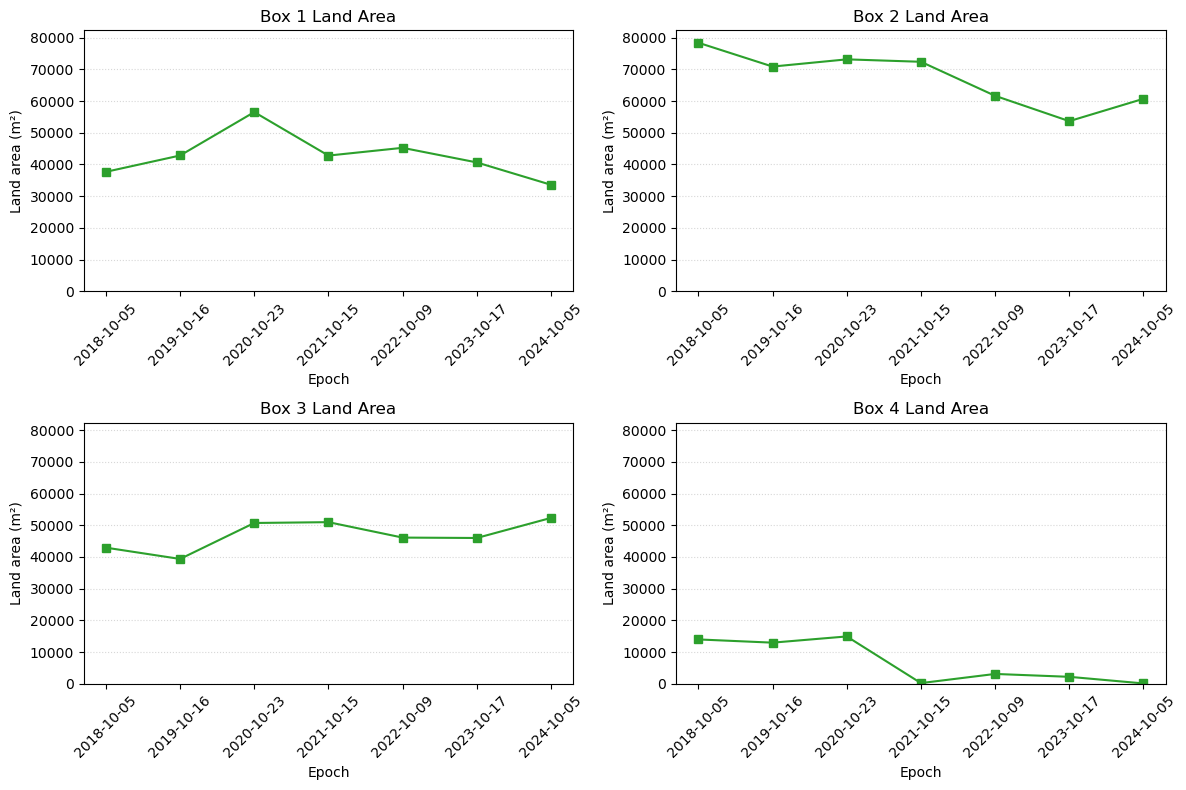

In [266]:
from datetime import datetime

# Count land pixels inside each world-aligned box per epoch and plot 4 line charts (one per box).


# boxes is defined in previous cells; selected_files too.
n_boxes = len(boxes)
if n_boxes == 0:
    raise RuntimeError("No boxes found in workspace (variable 'boxes').")

# prepare storage
dates = []
counts_per_box = {i: [] for i in range(n_boxes)}
areas_per_box = {i: [] for i in range(n_boxes)}  # optional: area in m^2

for fname in selected_files:
    path = os.path.join(folder, fname)
    try:
        # read transform and compute inv mapping for this raster
        with rasterio.open(path) as ds:
            transform = ds.transform
            w_img = ds.width
            h_img = ds.height

        # get stretched & labeled image (same logic as earlier)
        stretched = contrast_stretch_tif(path, output_path=None, p_low=15, p_high=98)
        bands = stretched.shape[0]
        if bands >= 3:
            img = stretched[:3].transpose(1, 2, 0)
        else:
            img = stretched.transpose(1, 2, 0)
            pad = np.zeros((img.shape[0], img.shape[1], 3 - img.shape[2]), dtype="float32")
            img = np.concatenate([img, pad], axis=2)

        h, w, _ = img.shape
        flat = img.reshape(-1, 3)

        km = KMeans(n_clusters=2, random_state=0).fit(flat)
        labels = km.labels_.reshape(h, w)
        counts = np.bincount(labels.flatten(), minlength=2)
        water_label = int(np.argmax(counts))
        land_label = int(np.argmin(counts))

        labels_remap = np.zeros_like(labels, dtype="uint8")
        labels_remap[labels == water_label] = 1
        labels_remap[labels == land_label] = 0
        labels = labels_remap

        # enforce global water_mask if available and same shape
        if 'water_mask' in globals() and water_mask.shape == labels.shape:
            labels = np.where(water_mask == 1, 1, labels)

        land_mask = (labels == 0)  # True => land

        # record date
        try:
            dt = datetime.strptime(fname[:10], "%Y-%m-%d")
        except Exception:
            dt = None
        dates.append(dt or fname)

        # per-box counts
        inv = ~transform  # world -> pixel for this file
        # meters-per-pixel (approx) from transform (use absolute values)
        mpp_x = abs(transform.a)
        mpp_y = abs(transform.e)
        mpp = (mpp_x + mpp_y) / 2.0 if (mpp_x > 0 and mpp_y > 0) else (mpp_x or mpp_y)

        for bi, b in enumerate(boxes):
            minx, miny, maxx, maxy = b
            # map corners to pixel coords using this raster's transform inverse
            tl = inv * (minx, maxy)  # top-left
            br = inv * (maxx, miny)  # bottom-right

            col_min_f = min(tl[0], br[0])
            col_max_f = max(tl[0], br[0])
            row_min_f = min(tl[1], br[1])
            row_max_f = max(tl[1], br[1])

            col0 = int(np.floor(col_min_f))
            row0 = int(np.floor(row_min_f))
            col1 = int(np.ceil(col_max_f))
            row1 = int(np.ceil(row_max_f))

            # clamp to image bounds
            col0 = max(0, min(w - 1, col0))
            col1 = max(0, min(w, col1))
            row0 = max(0, min(h - 1, row0))
            row1 = max(0, min(h, row1))

            if col1 <= col0 or row1 <= row0:
                # empty intersection
                counts_per_box[bi].append(0)
                areas_per_box[bi].append(0.0)
                continue

            sub = land_mask[row0:row1, col0:col1]
            n_land = int(np.count_nonzero(sub))
            counts_per_box[bi].append(n_land)
            areas_per_box[bi].append(n_land * (mpp * mpp))

    except Exception as e:
        print(f"Skipping {fname}: {e}")
        # maintain alignment with dates
        dates.append(None)
        for bi in range(n_boxes):
            counts_per_box[bi].append(0)
            areas_per_box[bi].append(0.0)

# prepare x axis: nicely formatted labels
x = [d.strftime("%Y-%m-%d") if isinstance(d, datetime) else str(d) for d in dates]

# Plot four charts (2x2) — one per box, with shared y limits
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# compute global y limits from areas_per_box
all_vals = np.hstack([np.asarray(areas_per_box[bi], dtype=float) for bi in range(n_boxes)])
ymin = 0.0
ymax = float(np.nanmax(all_vals)) if all_vals.size > 0 else 0.0
if ymax <= 0:
    ymax = 1.0
else:
    ymax *= 1.05  # small headroom

for bi in range(n_boxes):
    ax = axes[bi]
    y = areas_per_box[bi]  # land area in m^2
    ax.plot(x, y, marker='s', linestyle='-', color='tab:green')
    ax.set_title(f"Box {bi+1} Land Area")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Land area (m²)")
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

# hide any unused subplots (if n_boxes < 4)
for ai in range(n_boxes, len(axes)):
    axes[ai].axis('off')

plt.tight_layout()

out_img = os.path.join(img_folder, f"{season_name}_land_area_per_box.png")
os.makedirs(os.path.dirname(out_img), exist_ok=True)
fig.savefig(out_img, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved land area per box plot to: {out_img}")

plt.show()

In [263]:
import pandas as pd

# build dataframe with date as first column and one column per box (area in m^2)
df = pd.DataFrame({'date': pd.to_datetime(dates)})
for bi, vals in areas_per_box.items():
    df[f'box_{bi+1}_area_m2'] = vals

# ensure date is first column
df = df[['date'] + [c for c in df.columns if c != 'date']]

# save as csv
out_csv = os.path.join(img_folder, f"{season_name}_areas_per_box.csv")
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
df.to_csv(out_csv, index=False)
print(f"Saved CSV to: {out_csv}")

df

Saved CSV to: python_gen_img/late_areas_per_box.csv


,date,box_1_area_m2,box_2_area_m2,box_3_area_m2,box_4_area_m2
0,2018-10-05,37674.396054,78408.824276,42939.451403,13977.146935
1,2019-10-16,42831.450267,70893.745274,39375.413936,12960.136244
2,2020-10-23,56529.594270,73170.769211,50724.533244,14922.156870
3,2021-10-15,42804.449984,72405.761169,50985.535988,198.002082
4,2022-10-09,45252.475719,61668.648294,46116.484802,3087.032453
5,2023-10-17,40644.427276,53667.564183,45990.483477,2178.022897
6,2024-10-05,33588.353099,60723.638360,52326.550085,90.000946


In [234]:
n = 3
# print box 1 shape
print("Box 1 shape (world coords):", boxes[n])
# get col0, row0, ... for boxex[n]
col0, row0, col1, row1 = boxes[n]
# in pixels
print("Box 1 shape (pixel coords):", (col0, row0, col1, row1))
# number of pixels in box 1
print("Box 1 size (pixels):", (row1 - row0), "rows x", (col1 - col0), "cols")
# land size in meters squared (approx)
print("Box 1 size (meters squared):", (col1 - col0) * (row1 - row0) * (mpp * mpp), "m²")

Box 1 shape (world coords): (156000, 510000, 156400, 510400)
Box 1 shape (pixel coords): (156000, 510000, 156400, 510400)
Box 1 size (pixels): 400 rows x 400 cols
Box 1 size (meters squared): 1440015.1382220457 m²


## Area changes of all seasons

Saved plot to: python_gen_img/areas_per_box_all_seasons.png


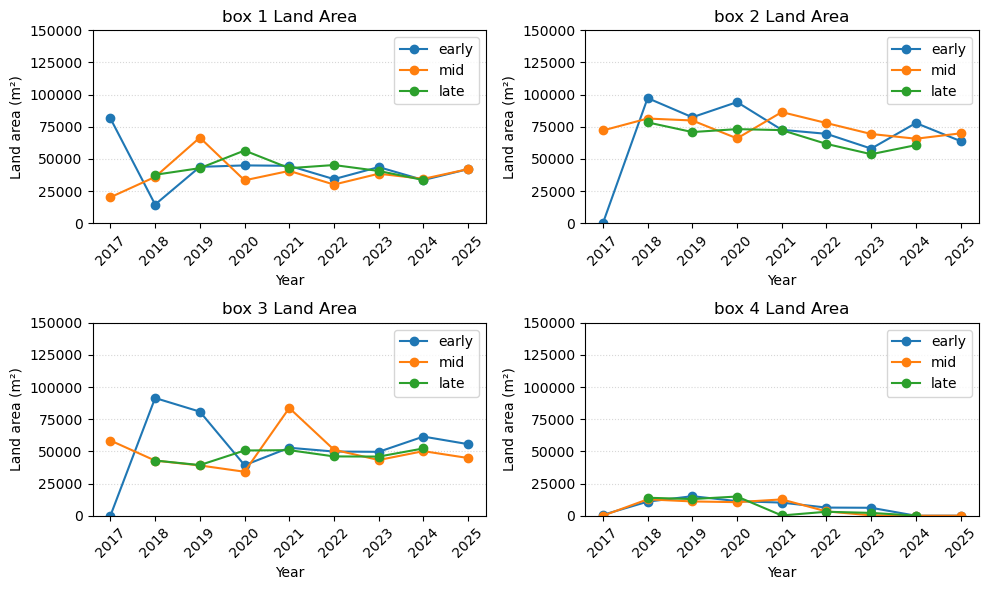

In [276]:
import os

# read three season CSVs, aggregate by year, and plot area time-series per box (early/mid/late)

# use existing img_folder if present, otherwise current dir
base = img_folder if ("img_folder" in globals() and img_folder) else "."

candidates = {
    "early": [os.path.join(base, "early_areas_per_box.csv"), os.path.join(base, "early_areas_per_box")],
    "mid":   [os.path.join(base, "mid_areas_per_box.csv"),   os.path.join(base, "mid_areas_per_box")],
    "late":  [os.path.join(base, "late_areas_per_box.csv"),  os.path.join(base, "late_areas_per_box")]
}

season_dfs = {}
for season, paths in candidates.items():
    p = next((pp for pp in paths if os.path.exists(pp)), None)
    if p is None:
        print(f"Warning: no CSV found for season '{season}' (looked for: {paths}). Skipping.")
        continue
    df_season = pd.read_csv(p)
    # ensure date col is datetime and extract year
    if "date" in df_season.columns:
        df_season["date"] = pd.to_datetime(df_season["date"], errors="coerce")
        df_season["year"] = df_season["date"].dt.year
    else:
        # try to infer a year column
        if "year" not in df_season.columns:
            raise RuntimeError(f"No 'date' or 'year' column in {p}")
    # group by year (average if multiple entries per year)
    df_year = df_season.groupby("year").mean(numeric_only=True).reset_index().set_index("year")
    season_dfs[season] = df_year

if not season_dfs:
    raise RuntimeError("No season data loaded. Check CSV files.")

# determine box columns (assume pattern 'box_#_area_m2')
all_box_cols = sorted({col for df in season_dfs.values() for col in df.columns if col.startswith("box_")})
if not all_box_cols:
    raise RuntimeError("No 'box_...' columns found in CSVs.")

# prepare union of years across seasons
all_years = sorted({int(y) for df in season_dfs.values() for y in df.index})
if not all_years:
    raise RuntimeError("No years found in data.")

# colors: prefer existing colors_local if available
try:
    palette = colors_local
except NameError:
    palette = plt.get_cmap("tab10").colors

seasons_order = ["early", "mid", "late"]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, box_col in enumerate(all_box_cols):
    ax = axes[i]
    for si, season in enumerate(seasons_order):
        if season not in season_dfs:
            continue
        sdf = season_dfs[season]
        # reindex to full union of years so missing years appear as gaps
        yseries = sdf.get(box_col)
        if yseries is None:
            continue
        yseries = yseries.reindex(all_years)
        ax.plot(all_years, yseries.values, marker="o", linestyle="-", label=season, color=palette[si % len(palette)])
    ax.set_title(box_col[:5].replace("_", " ") + " Land Area".title())
    ax.set_xlabel("Year")
    ax.set_ylabel("Land area (m²)")
    ax.set_ylim(0, 150000)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.set_xticks(all_years)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

# hide unused subplot(s) if any
for j in range(len(all_box_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

out_path = os.path.join(base, "areas_per_box_all_seasons.png")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved plot to: {out_path}")
plt.show()